In [1]:
%cd ../../

/Users/hoangle/Projects/untangling-people/fwo_models


In [2]:


import matplotlib.pyplot as plt

import pandas as pd
import polars as pl
import numpy as np
import holidays
from darts import TimeSeries
# from pytorch_lightning.callbacks import TQDMProgressBar
from darts import metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from darts.models import XGBModel, LightGBMModel, CatBoostModel, RegressionEnsembleModel, LinearRegressionModel
from darts.dataprocessing.transformers import Scaler, BoxCox, Diff
from sklearn.preprocessing import MinMaxScaler

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and dims

## Load and process data

In [4]:
EPS = 1e-6

In [5]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)



# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)



# Accum by restaurant and date
pos = (
    pos
    .with_columns(
        pl.col('datetime').dt.date().alias('date')
    )

    .group_by('restaurant', 'date')
    .agg(pl.col('pcs').sum())
)


# Trim records out of the range
DATE_MIN = pl.lit('2023-01-09').str.to_date()
DATE_MAX = pl.lit('2025-03-31').str.to_date()
pos = (
    pos.filter(pl.col('date') >= DATE_MIN)

    # make it possible for MAPE and log
    .with_columns((pl.col('pcs') + EPS))
)

pos.head()

restaurant,date,pcs
str,date,f64
"""exa""",2023-09-26,463.000001
"""phy""",2024-04-08,197.000001
"""phy""",2023-10-05,226.000001
"""che""",2024-08-19,639.000001
"""che""",2024-01-23,945.000001


In [6]:
pos_final = (
    pos
    .pivot(on='restaurant', index='date', values='pcs')
    .sort('date')
)

pos_final.head()

date,exa,phy,che,vik
date,f64,f64,f64,f64
2023-01-09,99.000001,33.000001,606.000001,280.000001
2023-01-10,207.000001,53.000001,525.000001,306.000001
2023-01-11,215.000001,67.000001,627.000001,266.000001
2023-01-12,160.000001,61.000001,602.000001,284.000001
2023-01-13,135.000001,56.000001,616.000001,149.000001


<Axes: xlabel='date'>

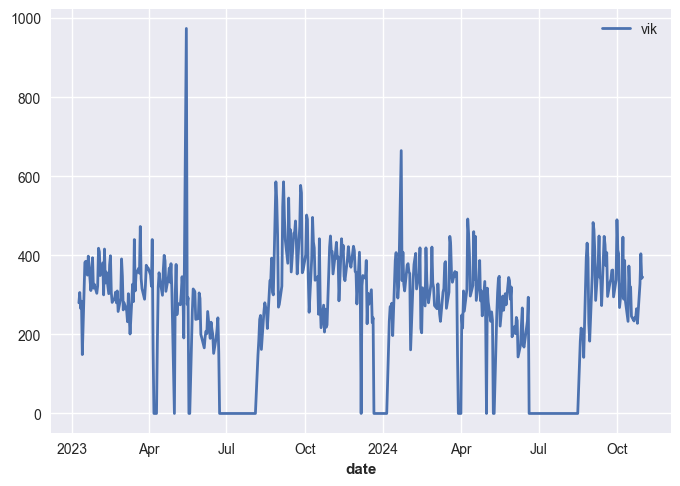

In [7]:
series = (
    TimeSeries
    .from_dataframe(
        pos_final.to_pandas(),
        time_col='date',
        value_cols=[
            # 'che',
            # 'exa',
            # 'phy',
            'vik'
        ],
        fillna_value=EPS,
        freq='B',
    )
    # .astype(np.float32)
)

series.plot()

In [8]:
# static_covs_multi = pd.DataFrame(data={"restaurant": [0, 1, 2, 3]})
# series = series.with_static_covariates(static_covs_multi)
# series.static_covariates

## Load dims

### `dim_exam`

In [9]:
dim_exam = (
    pl
    .from_records([
        {'date_begin': '2023-03-06', 'date_end': '2023-03-12'},  
        {'date_begin': '2023-05-01', 'date_end': '2023-05-07'},
        {'date_begin': '2023-10-23', 'date_end': '2023-10-29'},
        {'date_begin': '2023-12-18', 'date_end': '2023-12-24'},
        {'date_begin': '2024-03-04', 'date_end': '2024-03-10'},
        {'date_begin': '2024-05-06', 'date_end': '2024-05-12'},
        {'date_begin': '2024-10-21', 'date_end': '2024-10-27'},
        {'date_begin': '2025-03-03', 'date_end': '2025-03-09'},
    ])
    .with_columns(
        pl.col('date_begin').str.to_date(),
        pl.col('date_end').str.to_date(),
    )
)

dim_exam.head()

date_begin,date_end
date,date
2023-03-06,2023-03-12
2023-05-01,2023-05-07
2023-10-23,2023-10-29
2023-12-18,2023-12-24
2024-03-04,2024-03-10


In [10]:
df = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_MIN, DATE_MAX, '1d').alias('date')
    )
)

entries_exam = (
    df
    .join(dim_exam, how='cross')
    .filter(
        (pl.col('date') >= pl.col('date_begin'))
        & (pl.col('date') <= pl.col('date_end'))
    )
    .select(
        'date',
        pl.lit(1).alias('exam')
    )
)
cov_exam = (
    df
    .join(entries_exam, on='date', how='left')
    .with_columns(
        pl
        .col('exam')
        .fill_null(0)
        .cast(pl.String())
        .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)


cov_exam.head()

date,exam
date,cat
2023-01-09,"""0"""
2023-01-10,"""0"""
2023-01-11,"""0"""
2023-01-12,"""0"""
2023-01-13,"""0"""


<Axes: xlabel='date'>

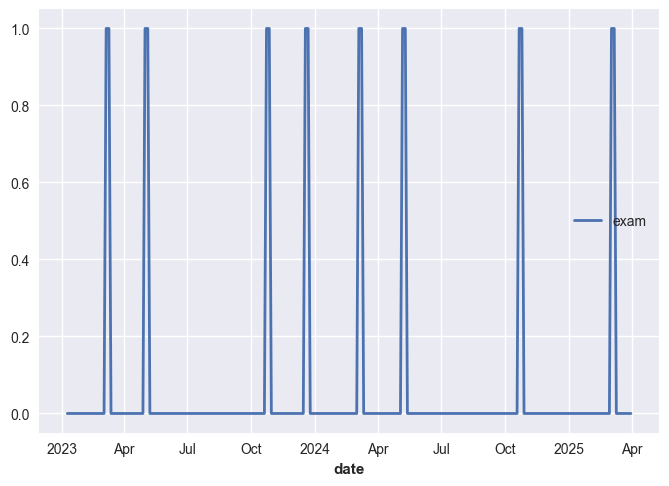

In [11]:
series_exam = (
    TimeSeries
    .from_dataframe(
        df=cov_exam.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='exam'
    )
    # .astype(np.float32)
)
series_exam.plot()

### `dim_holiday`

In [12]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])

dim_holiday.head()

date,name_holiday
date,str
2024-01-01,"""Uudenvuodenpäivä"""
2024-01-06,"""Loppiainen"""
2024-03-29,"""Pitkäperjantai"""
2024-03-31,"""Pääsiäispäivä"""
2024-04-01,"""Toinen pääsiäispäivä"""


In [13]:
cov_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_MIN, DATE_MAX, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('holiday'))
    .drop('name_holiday')


    # Cast to categorical type
    .with_columns(
        pl
        .col('holiday')
        .cast(pl.String())
        .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

cov_holiday.head()


date,holiday
date,cat
2023-01-09,"""0"""
2023-01-10,"""0"""
2023-01-11,"""0"""
2023-01-12,"""0"""
2023-01-13,"""0"""


<Axes: xlabel='date'>

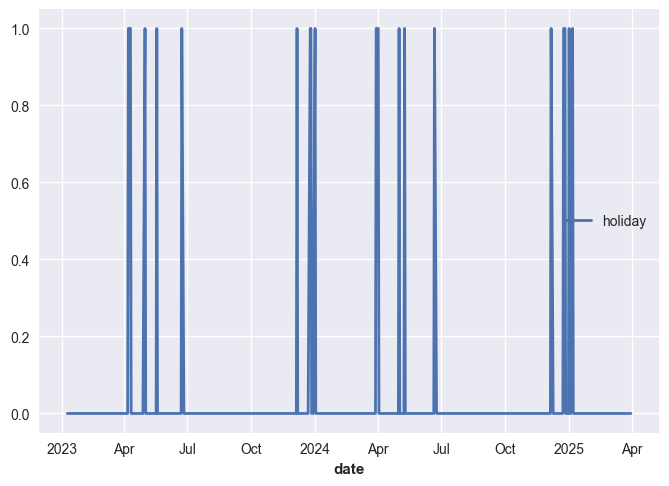

In [14]:
series_holiday = (
    TimeSeries
    .from_dataframe(
        df=cov_holiday.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='holiday'
    )
    # .astype(np.float32)
)
series_holiday.plot()

### `dim_bookings`

In [15]:
dim_bookings = pl.read_parquet("data/inter/dim_booking_crafted.parquet")

cov_booking = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_MIN, DATE_MAX, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_bookings, on='date', how='left')
    .fill_null(0)

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)

    # .drop
    .select('date', 'target_size', 'duration_coinciding', 'lecture_course', 'general_exam')
)
cov_booking.head()

date,target_size,duration_coinciding,lecture_course,general_exam
date,i64,f64,u32,u32
2023-01-09,15,3.0,1,0
2023-01-10,95,2.444444,2,0
2023-01-11,115,2.214286,1,2
2023-01-12,140,2.0,1,0
2023-01-13,295,2.15,0,1


<Axes: xlabel='date'>

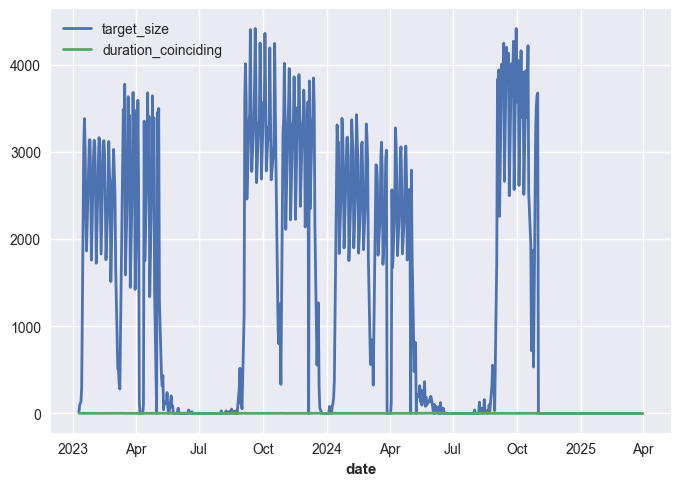

In [16]:
series_booking = (
    TimeSeries
    .from_dataframe(
        df=cov_booking.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols=[
            'target_size',
            'duration_coinciding',
            # 'lecture_course',
            # 'general_exam'
        ]
    )
    # .astype(np.float32)
)



series_booking.plot()

In [17]:
# transformer_cov_booking = Scaler(MinMaxScaler(feature_range=(-1, 1)))
# series_booking_transformed = transformer_cov_booking.fit_transform(series_booking)

# series_booking_transformed.plot()

# Train

In [18]:
CUTOFF_DATE = pd.to_datetime("2024-09-01")
series_train, series_test = series.split_before(CUTOFF_DATE)

series_cov = (
    series_exam
    # series_holiday
    .concatenate(series_holiday, axis=1)
    # .concatenate(series_booking, axis=1)
)

<Axes: xlabel='date'>

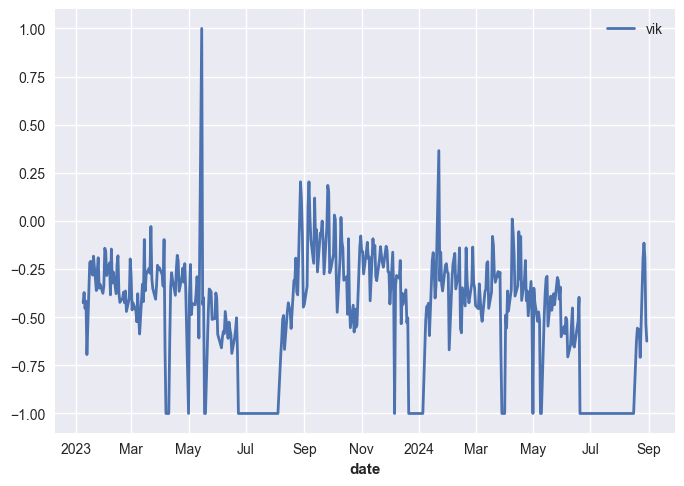

In [19]:
# transformer = Diff(1, dropna=True)
# series_transformed = transformer.fit_transform(series)
# series_train_diff = series_transformed.drop_after(CUTOFF_DATE)


series_train_transformed = series_train
# series_train_transformed = series_train_diff

transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
# transformer_target = BoxCox(lmbda=0.)
series_train_transformed = transformer_target.fit_transform(series_train_transformed)




series_train_transformed.plot()

## ML and statistical models

In [45]:
params = {
    "lags": 15,
    "lags_future_covariates": [0],
    # "input_chunk_length": 14,
    "output_chunk_length": 1,
    "add_encoders": {
        "datetime_attribute": {"future": [
            "dayofweek",
            # 'day',
            'month',
            # 'year'
        ]},
        'cyclic': {'future': [
            "dayofweek",
            # 'day',
            # 'month'
            ]},
        # 'transformer': Scaler(),
    },  # TFTModel requires future input, with this we won't have to supply any future_covariates
    # "categorical_embedding_sizes": {
    #     "holiday": (2, 2),
    #     "exam": (2, 2),
    #     "restaurant": (4, 4)
    # },
    # "n_epochs": 650,
    # "pl_trainer_kwargs": {
    #     "callbacks": [TQDMProgressBar(refresh_rate=4)],
    #     # 'precision': "32-true",
    # },
    # "optimizer_kwargs": {
    #     'lr': 5e-4
    # }
}
# model = XGBModel(**params)
model = CatBoostModel(**params)
# model = RegressionEnsembleModel(
#     forecasting_models=[
#         CatBoostModel(**params),
#         # XGBModel(**params),
#         # LinearRegressionModel(**params),
#         LightGBMModel(**params)
#     ],
#     regression_train_n_points=100,
#     train_using_historical_forecasts=True,
# )
model.fit(
    series_train_transformed,
    future_covariates=series_cov,
)

CatBoostModel(lags=15, lags_past_covariates=None, lags_future_covariates=[0], output_chunk_length=1, output_chunk_shift=0, add_encoders={'datetime_attribute': {'future': ['dayofweek', 'month']}, 'cyclic': {'future': ['dayofweek']}}, likelihood=None, quantiles=None, random_state=None, multi_models=True, use_static_covariates=True)

### TSMixer

In [21]:
# params = {
#     "input_chunk_length": 14,
#     "output_chunk_length": 1,
#     "add_encoders": {
#         "datetime_attribute": {"future": ["dayofweek", 'day', 'month', 'year']},
#         'cyclic': {'future': ["dayofweek", 'day', 'month']},
#         'transformer': Scaler(),
#     },  # TFTModel requires future input, with this we won't have to supply any future_covariates
#     # "categorical_embedding_sizes": {
#     #     "holiday": (2, 2),
#     #     "exam": (2, 2),
#     #     "restaurant": (4, 4)
#     # },
#     "n_epochs": 650,
#     "pl_trainer_kwargs": {
#         "callbacks": [TQDMProgressBar(refresh_rate=4)],
#         # 'precision': "32-true",
#     },
#     # "optimizer_kwargs": {
#     #     'lr': 5e-4
#     # }
# }
# model = TSMixerModel(**params)
# model.fit(
#     series_train_transformed,
#     future_covariates=series_cov,
# )

### Transformer

In [22]:
# params = {
#     "input_chunk_length": 7,
#     "output_chunk_length": 1,
#     "add_encoders": {
#         "datetime_attribute": {"past": ["dayofweek", 'day', 'month']},
#         'cyclic': {'past': ["dayofweek", 'day', 'month']},
#     },  # TFTModel requires future input, with this we won't have to supply any future_covariates
#     # "categorical_embedding_sizes": {
#     #     "holiday": (2, 2),
#     #     "exam": (2, 2),
#     #     "restaurant": (4, 4)
#     # },
#     "n_epochs": 300,
#     "pl_trainer_kwargs": {
#         "callbacks": [TQDMProgressBar(refresh_rate=4)],
#         # 'precision': "32-true",
#     },
#     # "optimizer_kwargs": {
#     #     'lr': 5e-4
#     # }
# }

# series_cov = (
#     series_exam
#     .concatenate(series_holiday, axis=1)
#     .concatenate(series_booking_transformed, axis=1)
# )
# model = TransformerModel(**params)
# model.fit(
#     series_train_transformed,
#     past_covariates=series_cov.split_before(cutoff_date)[0],
# )

### TFT

In [23]:
# params = {
#     "input_chunk_length": 14,
#     "output_chunk_length": 1,
#     "add_encoders": {
#         "datetime_attribute": {"future": ["dayofweek", 'day', 'month']},
#         'cyclic': {'future': ["dayofweek", 'day', 'month']},
#         'transformer': Scaler(),
#     },  # TFTModel requires future input, with this we won't have to supply any future_covariates
#     "categorical_embedding_sizes": {
#         "holiday": (2, 2),
#         "exam": (2, 2),
#         "restaurant": (4, 4)
#     },
#     "n_epochs": 650,
#     "pl_trainer_kwargs": {
#         "callbacks": [TQDMProgressBar(refresh_rate=4)],
#         # 'precision': "32-true",
#     },
#     # "optimizer_kwargs": {
#     #     'lr': 5e-4
#     # }
# }
# model = TFTModel(**params)
# model.fit(
#     series_train_transformed,
#     future_covariates=[
#         series_exam,
#         series_holiday,
#         series_booking_transformed
#     ],
# )

### Test

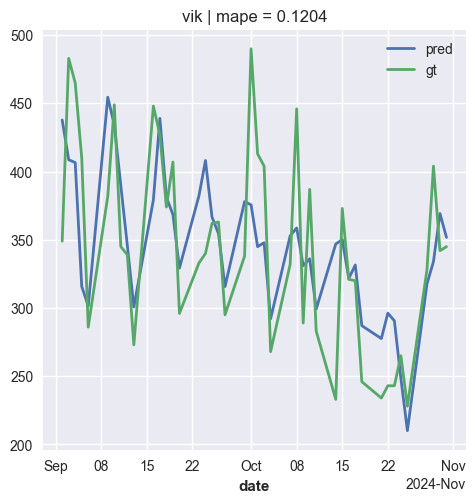

In [46]:
series_pred = model.predict(n=len(series_test), future_covariates=series_cov)
series_pred = transformer_target.inverse_transform(series_pred)
# series_pred = transformer.inverse_transform(series_train_diff.concatenate(series_pred)).drop_before(CUTOFF_DATE)

fig = plt.figure(figsize=(12, 12))

for idx, comp in enumerate(series_pred.components):
    ax = fig.add_subplot(2, 2, idx + 1)
    series_pred[comp].plot(ax=ax, label='pred')
    series_test[comp].plot(ax=ax, label='gt')
    # rmse_val = mape(series_test[comp], series_pred[comp])

    df = pd.concat(
        [
            series_test[comp].to_dataframe().rename(columns={comp: 'gt'}),
            series_pred[comp].to_dataframe().rename(columns={comp: 'pred'})
        ],
        axis=1
    )
    df = df[df['gt'] > EPS]
    mape_val = mean_absolute_percentage_error(df['gt'], df['pred'])

    ax.set_title(f"{comp} | mape = {mape_val:.4}")

# Train with entire data and forecast

In [47]:
transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
series_transformed = transformer_target.fit_transform(series)

model = CatBoostModel(**params)
model.fit(
    series_transformed,
    future_covariates=series_cov,
)

CatBoostModel(lags=15, lags_past_covariates=None, lags_future_covariates=[0], output_chunk_length=1, output_chunk_shift=0, add_encoders={'datetime_attribute': {'future': ['dayofweek', 'month']}, 'cyclic': {'future': ['dayofweek']}}, likelihood=None, quantiles=None, random_state=None, multi_models=True, use_static_covariates=True)

## Backtest

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.


<Axes: xlabel='time'>

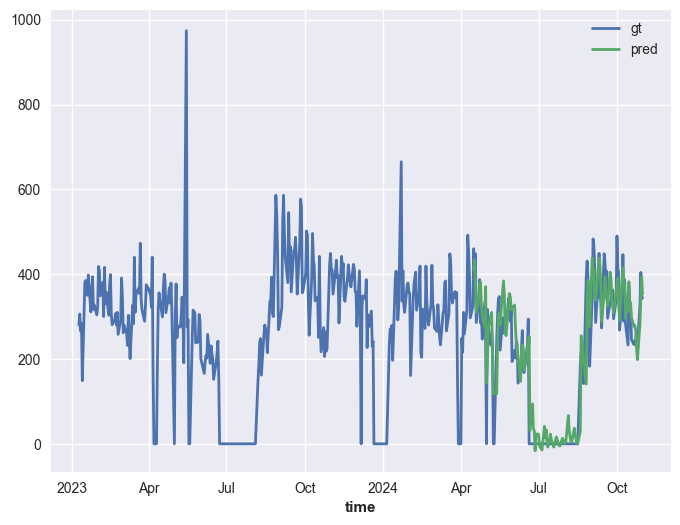

In [48]:
result = model.historical_forecasts(series_transformed, start=.7, future_covariates=series_cov, forecast_horizon=1)
result = transformer_target.inverse_transform(result)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

series.plot(ax=ax, label='gt')
result.plot(ax=ax, label='pred')

## Forecast and save

In [49]:
N = 107
series_pred = model.predict(n=N, future_covariates=series_cov)
series_pred = transformer_target.inverse_transform(series_pred)


series_pred.to_dataframe().to_excel("data/inter/evaluation/vikkuna_Apr1.xlsx")